In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [151]:
df = pd.read_csv("yield_prediction_dataset.csv")

In [152]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,Soil_OC,Fertilizer_kg_ha,Pest_Index,Irrigation_mm,label,Yield_t_ha
0,90.0,42.0,43.0,20.879744,82.002744,6.502985,202.935536,1.249671,252.065222,0.786962,308.380046,rice,3.61
1,85.0,58.0,41.0,21.770462,80.319644,7.038096,226.655537,1.136174,231.136443,0.837722,325.097947,rice,3.35
2,60.0,55.0,44.0,23.004459,82.320763,7.840207,263.964248,0.964769,219.796369,0.801913,313.414362,rice,3.12
3,74.0,35.0,40.0,26.491096,80.158363,6.980401,242.864034,1.192303,179.600906,0.822199,319.787474,rice,3.29
4,78.0,42.0,42.0,20.130175,81.604873,7.628473,262.717340,1.056585,197.653454,0.833660,285.493030,rice,3.44


In [153]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8800 entries, 0 to 8799
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   N                 8800 non-null   float64
 1   P                 8800 non-null   float64
 2   K                 8800 non-null   float64
 3   temperature       8800 non-null   float64
 4   humidity          8800 non-null   float64
 5   ph                8800 non-null   float64
 6   rainfall          8800 non-null   float64
 7   Soil_OC           8800 non-null   float64
 8   Fertilizer_kg_ha  8800 non-null   float64
 9   Pest_Index        8800 non-null   float64
 10  Irrigation_mm     8800 non-null   float64
 11  label             8800 non-null   object 
 12  Yield_t_ha        8800 non-null   float64
dtypes: float64(12), object(1)
memory usage: 893.9+ KB


In [154]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall,Soil_OC,Fertilizer_kg_ha,Pest_Index,Irrigation_mm,Yield_t_ha
count,8800.000000,8800.000000,8800.000000,8800.000000,8800.000000,8800.000000,8800.000000,8800.000000,8800.000000,8800.000000,8800.000000,8800.000000
mean,50.559605,53.395644,48.152880,25.614268,71.475447,6.468425,103.446535,0.809102,201.743757,0.565995,446.627206,9.262877
std,37.216612,33.080419,50.690013,5.140908,22.336965,0.779562,55.564999,0.385498,81.594415,0.170070,65.159439,10.465673
min,-11.849956,-1.877115,-4.680960,8.052542,9.863400,3.404463,-4.444531,0.040498,40.774409,0.000000,202.739632,0.500000
25%,20.817706,28.271715,20.458427,22.572038,59.825294,5.962125,63.468642,0.504243,143.413467,0.464568,408.417199,1.540000
50%,37.265150,50.974983,31.836436,25.638779,80.144171,6.420939,94.300300,0.705325,191.722230,0.576806,454.838967,3.300000
75%,84.390147,68.000000,48.745542,28.562677,89.328508,6.920304,127.704591,1.132551,231.507959,0.684031,492.139262,15.640000
max,150.431074,152.365662,213.660873,44.515611,102.477597,10.008668,310.352623,1.922192,478.290438,1.000000,625.562974,45.340000


In [155]:
# df.duplicated().sum()
df.isnull().sum()

N                   0
P                   0
K                   0
temperature         0
humidity            0
ph                  0
rainfall            0
Soil_OC             0
Fertilizer_kg_ha    0
Pest_Index          0
Irrigation_mm       0
label               0
Yield_t_ha          0
dtype: int64

In [156]:
df.nunique()

N                   6737
P                   6717
K                   6673
temperature         8800
humidity            8800
ph                  8800
rainfall            8800
Soil_OC             8800
Fertilizer_kg_ha    8800
Pest_Index          8790
Irrigation_mm       8800
label                 22
Yield_t_ha          2028
dtype: int64

In [157]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

encoder = OneHotEncoder(sparse_output=False)  # IMPORTANT

encoded = encoder.fit_transform(df[['label']])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['label'])
)

df = df.drop('label', axis=1)
df = pd.concat([df, encoded_df], axis=1)

In [158]:
df.isnull().sum()

N                    0
P                    0
K                    0
temperature          0
humidity             0
ph                   0
rainfall             0
Soil_OC              0
Fertilizer_kg_ha     0
Pest_Index           0
Irrigation_mm        0
Yield_t_ha           0
label_apple          0
label_banana         0
label_blackgram      0
label_chickpea       0
label_coconut        0
label_coffee         0
label_cotton         0
label_grapes         0
label_jute           0
label_kidneybeans    0
label_lentil         0
label_maize          0
label_mango          0
label_mothbeans      0
label_mungbean       0
label_muskmelon      0
label_orange         0
label_papaya         0
label_pigeonpeas     0
label_pomegranate    0
label_rice           0
label_watermelon     0
dtype: int64

In [159]:
df.shape

(8800, 34)

In [160]:
import numpy as np

# Remove invalid values
df = df[df['N'] >= 0]
df = df[df['rainfall'] >= 0]

# Clip based on boxplot/domain
df['P'] = df['P'].clip(upper=120)
df['K'] = df['K'].clip(upper=120)
df['ph'] = df['ph'].clip(4, 9)

df['rainfall'] = df['rainfall'].clip(upper=250)

df['Fertilizer_kg_ha'] = df['Fertilizer_kg_ha'].clip(upper=350)

df['Irrigation_mm'] = df['Irrigation_mm'].clip(250, 600)

In [161]:
df['Yield_t_ha'] = np.log1p(df['Yield_t_ha'])

In [162]:
X = df.drop('Yield_t_ha', axis=1)
y = df['Yield_t_ha']

In [163]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [164]:
from sklearn.model_selection import train_test_split

# Train-Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train-Validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42
)

GB Epoch 1 | Train RMSE: 0.9374 | Val RMSE: 0.9301
GB Epoch 2 | Train RMSE: 0.8622 | Val RMSE: 0.8566
GB Epoch 3 | Train RMSE: 0.7929 | Val RMSE: 0.7898
GB Epoch 4 | Train RMSE: 0.7321 | Val RMSE: 0.7305
GB Epoch 5 | Train RMSE: 0.6785 | Val RMSE: 0.6787
GB Epoch 6 | Train RMSE: 0.6284 | Val RMSE: 0.6300
GB Epoch 7 | Train RMSE: 0.5854 | Val RMSE: 0.5882
GB Epoch 8 | Train RMSE: 0.5451 | Val RMSE: 0.5501
GB Epoch 9 | Train RMSE: 0.5097 | Val RMSE: 0.5168
GB Epoch 10 | Train RMSE: 0.4781 | Val RMSE: 0.4860
GB Epoch 11 | Train RMSE: 0.4503 | Val RMSE: 0.4604
GB Epoch 12 | Train RMSE: 0.4256 | Val RMSE: 0.4375
GB Epoch 13 | Train RMSE: 0.3995 | Val RMSE: 0.4109
GB Epoch 14 | Train RMSE: 0.3795 | Val RMSE: 0.3922
GB Epoch 15 | Train RMSE: 0.3589 | Val RMSE: 0.3728
GB Epoch 16 | Train RMSE: 0.3405 | Val RMSE: 0.3539
GB Epoch 17 | Train RMSE: 0.3253 | Val RMSE: 0.3396
GB Epoch 18 | Train RMSE: 0.3103 | Val RMSE: 0.3242
GB Epoch 19 | Train RMSE: 0.2945 | Val RMSE: 0.3088
GB Epoch 20 | Train R

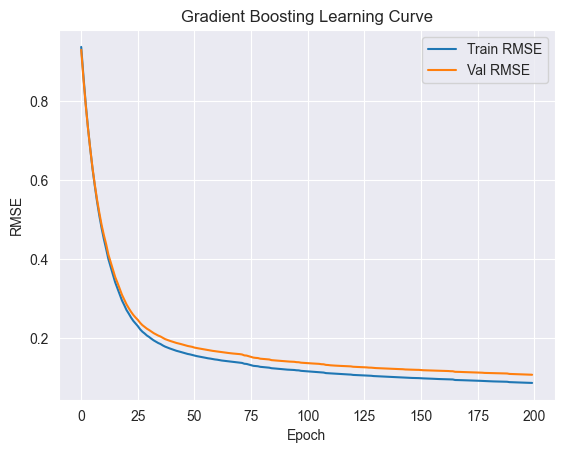

In [166]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train, y_train)

gb_train_errors = []
gb_val_errors = []

# Train errors
for y_pred in gbr.staged_predict(X_train):
    gb_train_errors.append(np.sqrt(mean_squared_error(y_train, y_pred)))

# Val errors
for y_pred in gbr.staged_predict(X_val):
    gb_val_errors.append(np.sqrt(mean_squared_error(y_val, y_pred)))

# Print epoch-wise
for i in range(len(gb_train_errors)):
    print(f"GB Epoch {i+1} | Train RMSE: {gb_train_errors[i]:.4f} | Val RMSE: {gb_val_errors[i]:.4f}")

# Plot
plt.figure()
plt.plot(gb_train_errors, label="Train RMSE")
plt.plot(gb_val_errors, label="Val RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Gradient Boosting Learning Curve")
plt.legend()
plt.show()

In [169]:
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train, y_train)

train_errors = []
val_errors = []

# Track errors
for y_pred in gbr.staged_predict(X_train):
    train_errors.append(np.sqrt(mean_squared_error(y_train, y_pred)))

for y_pred in gbr.staged_predict(X_val):
    val_errors.append(np.sqrt(mean_squared_error(y_val, y_pred)))

# Find best epoch
best_epoch = np.argmin(val_errors)
print("Best Epoch:", best_epoch + 1)

# Retrain with best epoch
best_model = GradientBoostingRegressor(
    n_estimators=best_epoch + 1,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

best_model.fit(X_train, y_train)

Best Epoch: 200


,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",np.int64(200)
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples i

In [170]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=True
)

[0]	validation_0-rmse:0.92881	validation_1-rmse:0.92127
[1]	validation_0-rmse:0.84375	validation_1-rmse:0.83892
[2]	validation_0-rmse:0.76858	validation_1-rmse:0.76619
[3]	validation_0-rmse:0.70113	validation_1-rmse:0.70067
[4]	validation_0-rmse:0.63942	validation_1-rmse:0.64126
[5]	validation_0-rmse:0.58579	validation_1-rmse:0.58907
[6]	validation_0-rmse:0.53665	validation_1-rmse:0.54198
[7]	validation_0-rmse:0.49260	validation_1-rmse:0.49816
[8]	validation_0-rmse:0.45340	validation_1-rmse:0.46018
[9]	validation_0-rmse:0.41856	validation_1-rmse:0.42709
[10]	validation_0-rmse:0.38680	validation_1-rmse:0.39564
[11]	validation_0-rmse:0.35865	validation_1-rmse:0.36904
[12]	validation_0-rmse:0.33254	validation_1-rmse:0.34420
[13]	validation_0-rmse:0.30949	validation_1-rmse:0.32221
[14]	validation_0-rmse:0.28957	validation_1-rmse:0.30272
[15]	validation_0-rmse:0.26980	validation_1-rmse:0.28346
[16]	validation_0-rmse:0.25323	validation_1-rmse:0.26780
[17]	validation_0-rmse:0.23890	validation

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

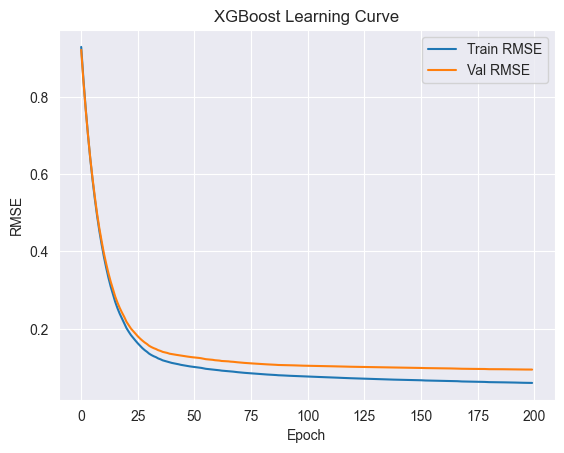

In [171]:
results = xgb.evals_result()

train_rmse = results['validation_0']['rmse']
val_rmse = results['validation_1']['rmse']

import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_rmse, label="Train RMSE")
plt.plot(val_rmse, label="Val RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("XGBoost Learning Curve")
plt.legend()
plt.show()

              Feature  Importance
2                   K    0.315726
4            humidity    0.284132
1                   P    0.100475
23        label_mango    0.071742
25     label_mungbean    0.038646
28       label_papaya    0.037239
12       label_banana    0.020492
6            rainfall    0.019754
19         label_jute    0.018213
16       label_coffee    0.015621
31         label_rice    0.015119
27       label_orange    0.013683
3         temperature    0.011420
5                  ph    0.008909
8    Fertilizer_kg_ha    0.007214
22        label_maize    0.006079
0                   N    0.005530
32   label_watermelon    0.003633
24    label_mothbeans    0.003530
7             Soil_OC    0.000848
13    label_blackgram    0.000590
18       label_grapes    0.000480
17       label_cotton    0.000255
26    label_muskmelon    0.000239
30  label_pomegranate    0.000114
11        label_apple    0.000098
29   label_pigeonpeas    0.000069
14     label_chickpea    0.000054
20  label_kidn

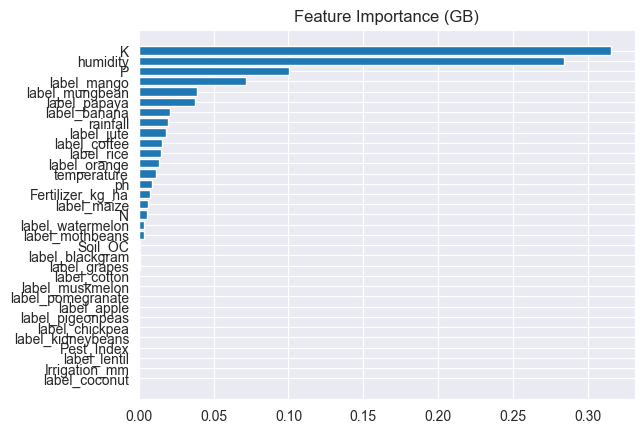

In [172]:
import pandas as pd
import matplotlib.pyplot as plt

importance = best_model.feature_importances_
features = X_train.columns

imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(imp_df)

# Plot
plt.figure()
plt.barh(imp_df['Feature'], imp_df['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance (GB)")
plt.show()

              Feature  Importance
4            humidity    0.186682
23        label_mango    0.154228
25     label_mungbean    0.100867
2                   K    0.093195
31         label_rice    0.062642
28       label_papaya    0.057153
15      label_coconut    0.053226
16       label_coffee    0.047141
12       label_banana    0.045901
1                   P    0.042704
19         label_jute    0.037733
22        label_maize    0.028176
6            rainfall    0.021531
27       label_orange    0.013778
0                   N    0.010728
32   label_watermelon    0.009640
11        label_apple    0.007000
24    label_mothbeans    0.006045
3         temperature    0.004353
8    Fertilizer_kg_ha    0.003216
18       label_grapes    0.002402
30  label_pomegranate    0.002128
5                  ph    0.002112
17       label_cotton    0.002030
26    label_muskmelon    0.001604
7             Soil_OC    0.001000
13    label_blackgram    0.000730
29   label_pigeonpeas    0.000534
21       label

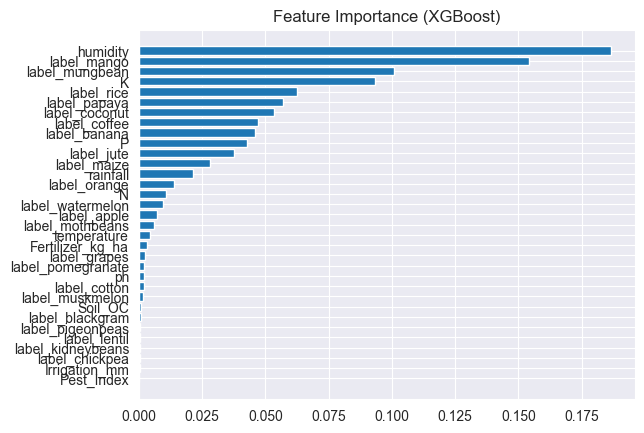

In [173]:
importance = xgb.feature_importances_

imp_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(imp_df)

plt.figure()
plt.barh(imp_df['Feature'], imp_df['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance (XGBoost)")
plt.show()

In [176]:
import optuna
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor
import numpy as np

def objective_gb(trial):
    model = GradientBoostingRegressor(
        n_estimators=trial.suggest_int('n_estimators', 50, 200),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.2),
        max_depth=trial.suggest_int('max_depth', 2, 5),
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    return rmse

study = optuna.create_study(direction='minimize')
study.optimize(objective_gb, n_trials=20)

print("Best Params:", study_gb.best_params)

[I 2026-04-05 00:24:34,183] A new study created in memory with name: no-name-4f14705d-1e50-4833-92c6-1b25115954cb
[I 2026-04-05 00:24:35,304] Trial 0 finished with value: 0.10096880139836595 and parameters: {'n_estimators': 63, 'learning_rate': 0.17865674741670906, 'max_depth': 5}. Best is trial 0 with value: 0.10096880139836595.
[I 2026-04-05 00:24:36,617] Trial 1 finished with value: 0.3980259202359256 and parameters: {'n_estimators': 94, 'learning_rate': 0.012106494581679754, 'max_depth': 4}. Best is trial 0 with value: 0.10096880139836595.
[I 2026-04-05 00:24:37,563] Trial 2 finished with value: 0.12981046223895654 and parameters: {'n_estimators': 67, 'learning_rate': 0.06654351997331635, 'max_depth': 4}. Best is trial 0 with value: 0.10096880139836595.
[I 2026-04-05 00:24:40,309] Trial 3 finished with value: 0.0986670070088104 and parameters: {'n_estimators': 192, 'learning_rate': 0.05837872538651578, 'max_depth': 4}. Best is trial 3 with value: 0.0986670070088104.
[I 2026-04-05 0

Best Params: {'n_estimators': 159, 'learning_rate': 0.1629968354244898, 'max_depth': 3}


In [177]:
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

def objective_xgb(trial):
    model = XGBRegressor(
        n_estimators=trial.suggest_int('n_estimators', 100, 300),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.2),
        max_depth=trial.suggest_int('max_depth', 3, 6),
        subsample=trial.suggest_float('subsample', 0.7, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.7, 1.0),
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    return rmse

study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=30)

print("Best Params:", study_xgb.best_params)

[I 2026-04-05 00:25:31,804] A new study created in memory with name: no-name-40846610-51ee-4a9e-94fb-a42732b5ec12
[I 2026-04-05 00:25:32,066] Trial 0 finished with value: 0.11773701325022455 and parameters: {'n_estimators': 215, 'learning_rate': 0.025813109070746458, 'max_depth': 4, 'subsample': 0.7597776126285257, 'colsample_bytree': 0.7817286840051373}. Best is trial 0 with value: 0.11773701325022455.
[I 2026-04-05 00:25:32,204] Trial 1 finished with value: 0.08860056873203533 and parameters: {'n_estimators': 129, 'learning_rate': 0.13738232319274332, 'max_depth': 4, 'subsample': 0.9204922073737509, 'colsample_bytree': 0.8264480013889554}. Best is trial 1 with value: 0.08860056873203533.
[I 2026-04-05 00:25:32,407] Trial 2 finished with value: 0.0971474572305075 and parameters: {'n_estimators': 191, 'learning_rate': 0.05401339226933746, 'max_depth': 4, 'subsample': 0.7103721559694264, 'colsample_bytree': 0.7355079326637881}. Best is trial 1 with value: 0.08860056873203533.
[I 2026-04

Best Params: {'n_estimators': 298, 'learning_rate': 0.17605006585973212, 'max_depth': 4, 'subsample': 0.8462267206453731, 'colsample_bytree': 0.815368523851296}


In [178]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=159,
    learning_rate=0.1629968354244898,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1629968354244898
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",159
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samp

In [179]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=298,
    learning_rate=0.17605006585973212,
    max_depth=4,
    subsample=0.8462267206453731,
    colsample_bytree=0.815368523851296,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.815368523851296
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import 

In [180]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Gradient Boosting
gb_pred = gb_model.predict(X_val)
gb_rmse = np.sqrt(mean_squared_error(y_val, gb_pred))
gb_r2 = r2_score(y_val, gb_pred)

# XGBoost
xgb_pred = xgb_model.predict(X_val)
xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_pred))
xgb_r2 = r2_score(y_val, xgb_pred)

print("Gradient Boosting → RMSE:", gb_rmse, "R2:", gb_r2)
print("XGBoost → RMSE:", xgb_rmse, "R2:", xgb_r2)

Gradient Boosting → RMSE: 0.09796517956114723 R2: 0.9906409081733366
XGBoost → RMSE: 0.07970723024153391 R2: 0.993804367250293


In [181]:
# Gradient Boosting
gb_test_pred = gb_model.predict(X_test)
print("GB Test RMSE:", np.sqrt(mean_squared_error(y_test, gb_test_pred)))

# XGBoost
xgb_test_pred = xgb_model.predict(X_test)
print("XGB Test RMSE:", np.sqrt(mean_squared_error(y_test, xgb_test_pred)))

GB Test RMSE: 0.09630198361283773
XGB Test RMSE: 0.07920354006411601


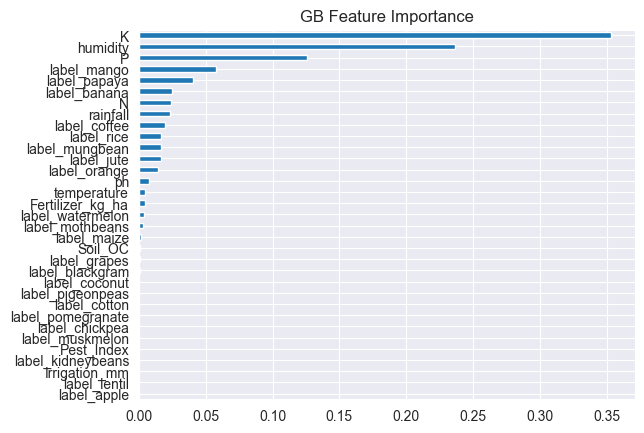

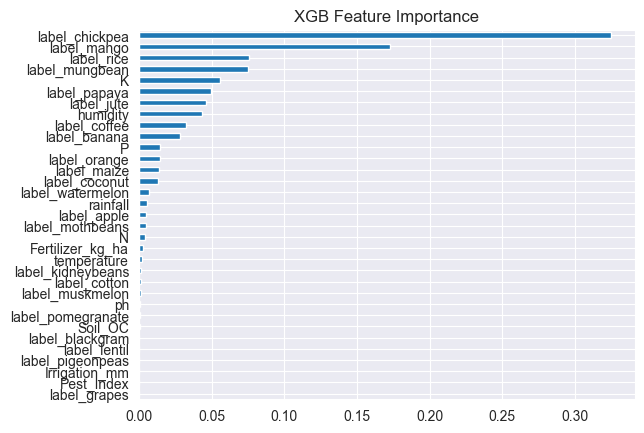

In [182]:
import pandas as pd
import matplotlib.pyplot as plt

# GB importance
gb_imp = pd.Series(gb_model.feature_importances_, index=X_train.columns)

# XGB importance
xgb_imp = pd.Series(xgb_model.feature_importances_, index=X_train.columns)

# Plot
plt.figure()
gb_imp.sort_values().plot(kind='barh', title='GB Feature Importance')
plt.show()

plt.figure()
xgb_imp.sort_values().plot(kind='barh', title='XGB Feature Importance')
plt.show()

In [183]:
print("Model Comparison:")
print(f"GB RMSE: {gb_rmse:.4f}")
print(f"XGB RMSE: {xgb_rmse:.4f}")

Model Comparison:
GB RMSE: 0.0980
XGB RMSE: 0.0797


In [193]:
import shap

# Create explainer
explainer = shap.TreeExplainer(xgb_model)

# Compute SHAP values
shap_values = explainer.shap_values(X_val)

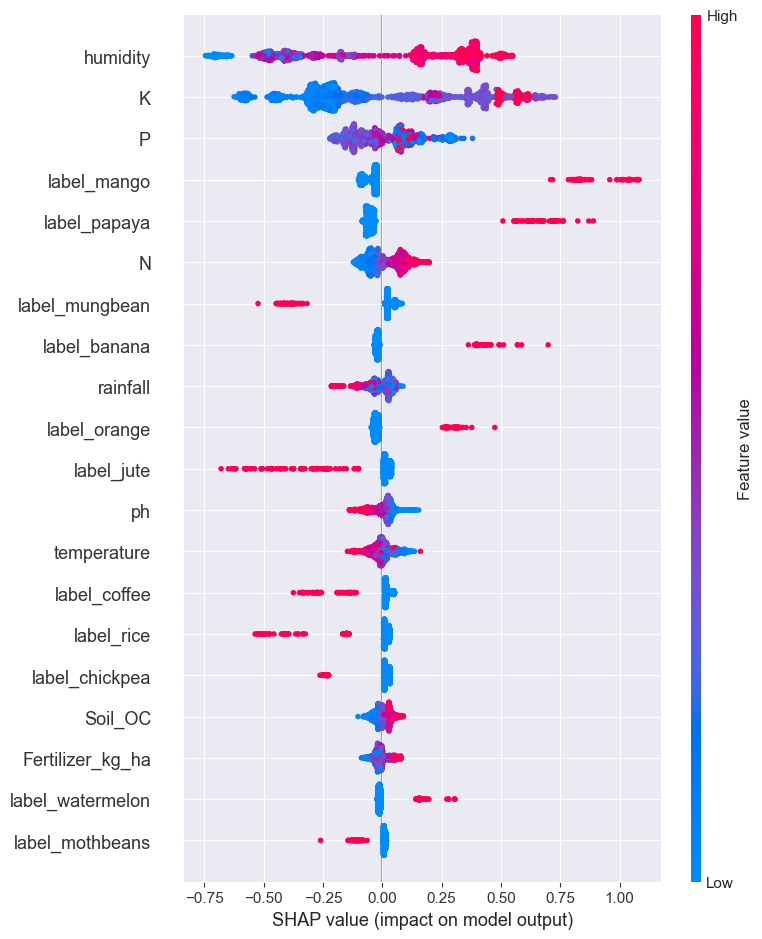

In [194]:
shap.summary_plot(shap_values, X_val)

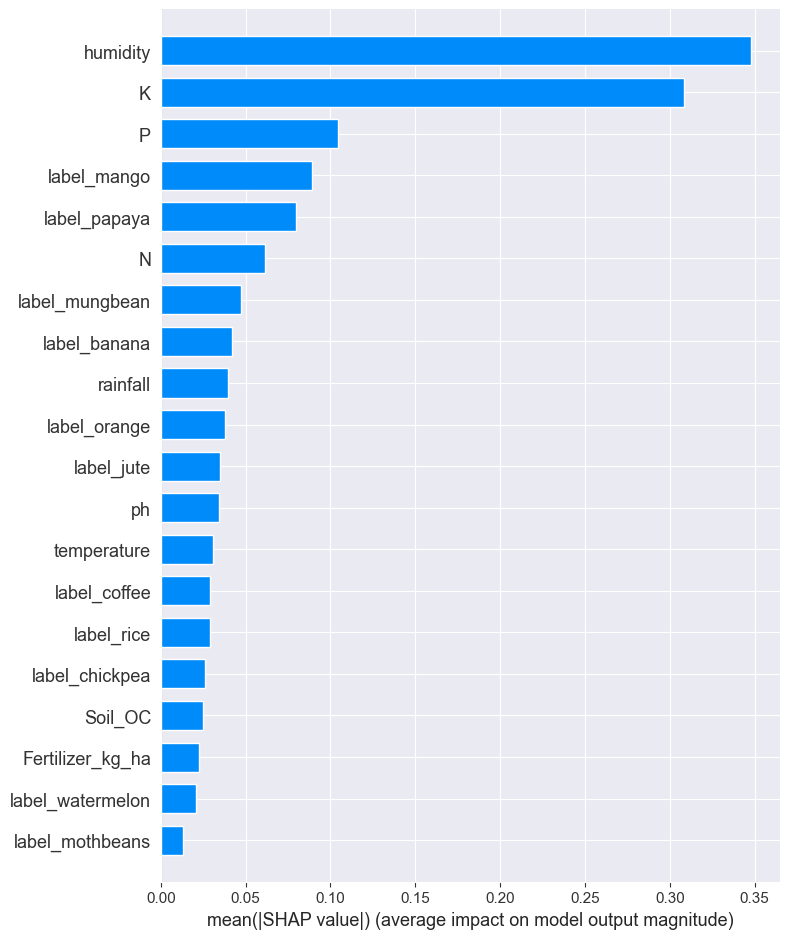

In [187]:
shap.summary_plot(shap_values, X_val, plot_type="bar")

In [188]:
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_val.iloc[0]
)

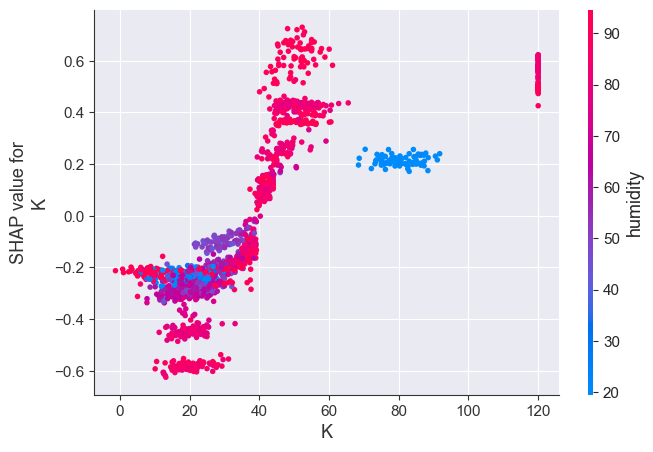

In [190]:
shap.dependence_plot("K", shap_values, X_val)

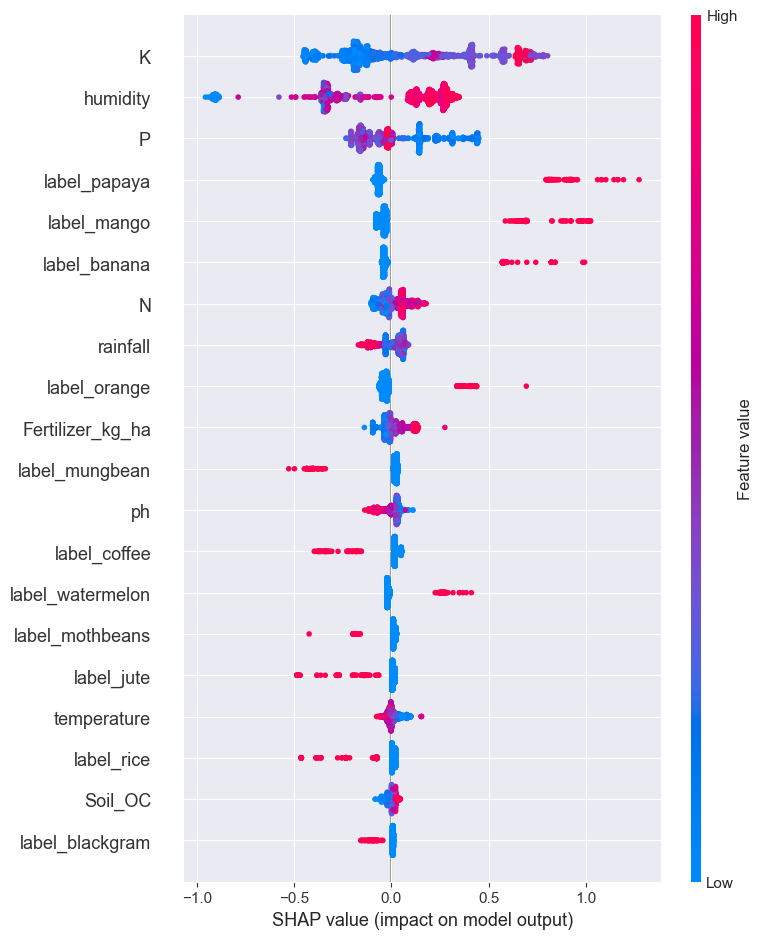

In [191]:
explainer_gb = shap.TreeExplainer(gb_model)
shap_values_gb = explainer_gb.shap_values(X_val)

shap.summary_plot(shap_values_gb, X_val)